# File for dimensionality reduction and clustering

#### Importing packages:

In [146]:
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
import umap
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster

#### Getting data imported:

In [147]:
#Using this to get the photo names:
image_example_path = "C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\images"
image_file_names = [f for f in listdir(image_example_path) if isfile(join(image_example_path, f))]

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Chris\AppData\Local\Temp\ipykernel_17772\41473570.py:2: SyntaxWarning: invalid escape sequence '\C'
  image_example_path = "C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\images"


In [148]:
#printed so it´s not only me that can see it(change path to the one that works for you if you want the code to work)
print(image_file_names)

['0_left.webp', '0_right.webp', '1_left.webp', '1_right.webp', '2_left.webp', '2_right.webp', '3_left.webp', '3_right.webp', '4_left.webp', '4_right.webp', '5_left.webp', '5_right.webp', '6_left.webp', '6_right.webp', '7_left.webp', '7_right.webp', '8_left.webp', '8_right.webp', '9_left.webp', '9_right.webp']


In [149]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_image_clustering = []


#Folder with folders of images:
base_folder = r"C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\scrandle_padded_low_res_data"
#Meta data folders(yes, a bit inefficient):
meta_folder = r"C:/Users\Chris\Documents\GitHub\scrandle_ml_project\attempt-18-05-2026\ulle-workspace\grand_scraper_folder\scrandle_data"


#Looping over all dates in the listed directory/folder:
for date in sorted(os.listdir(base_folder)):
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {date}")

    #Looping over all images in the given folder:
    for i in range(len(image_file_names)):
        image_path = os.path.join(date_path, image_file_names[i])
        image_Data_low_res.append({
                "date": date,
                "image_name": image_file_names[i],
                "RGB": plt.imread(image_path, format="webp"),
            })
    
    #Finding the other metadata:
    data_path = os.path.join(meta_date_path, "meta.csv")
    meta_intermediate = pd.read_csv(data_path)
    metadata_image_clustering.append({
                "price": meta_intermediate["price"],
                "rating": meta_intermediate["rating"],
                "year": meta_intermediate["year"],
            })

Processing 2025-04-01
Processing 2025-04-02
Processing 2025-04-03
Processing 2025-04-04
Processing 2025-04-05
Processing 2025-04-06
Processing 2025-04-07
Processing 2025-04-08
Processing 2025-04-09
Processing 2025-04-10
Processing 2025-04-11
Processing 2025-04-12
Processing 2025-04-13
Processing 2025-04-14
Processing 2025-04-15
Processing 2025-04-16
Processing 2025-04-17
Processing 2025-04-18
Processing 2025-04-19
Processing 2025-04-20
Processing 2025-04-21
Processing 2025-04-22
Processing 2025-04-23
Processing 2025-04-24
Processing 2025-04-25
Processing 2025-04-26
Processing 2025-04-27
Processing 2025-04-28
Processing 2025-04-29
Processing 2025-04-30
Processing 2025-05-01
Processing 2025-05-02
Processing 2025-05-03
Processing 2025-05-04
Processing 2025-05-05
Processing 2025-05-06
Processing 2025-05-07
Processing 2025-05-08
Processing 2025-05-09
Processing 2025-05-10
Processing 2025-05-11
Processing 2025-05-12
Processing 2025-05-13
Processing 2025-05-14
Processing 2025-05-15
Processing

In [150]:
#Now, we want to convert the images to a gigantic pandas dataframe, where each pixel of the image corresponds to 3 variables(R, G, and B)
#First, let´s remove the extra meta data to only have the pictures(likely a better way. Am very open to suggestions):
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

In [151]:
#Now, we use this list to make a matrix, which we´ll then convert to a pandas dataframe
#NOTE: triple loop. Can likely be optimized, and i´m, again, very open to suggestions...
image_pixels = []
for k in range(len(image_only_low_res)):
    image_RGB = []
    for i in range(100):
        for j in range(3):
            image_RGB.append(image_only_low_res[k][i].T[j])
    image_RGB = np.hstack(image_RGB)
    image_pixels.append(image_RGB)
image_pixels = np.vstack(image_pixels)
image_pixel_dataframe = pd.DataFrame(image_pixels)

In [152]:
#This is here so you can see the format(without having to run it all and change the directories):
image_pixel_dataframe

,0,1,2,3,4,5,6,7,8,9,...,25490,25491,25492,25493,25494,25495,25496,25497,25498,25499
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,25,24,24,24,24,22,19,18,4,2
2,0,0,0,0,0,0,0,0,0,0,...,164,158,163,163,157,155,161,162,176,166
3,0,0,0,0,0,0,0,0,0,0,...,99,103,125,55,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,24,26,28,30,31,29,28,29,29,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8275,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8276,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8277,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8278,0,0,0,0,0,0,0,0,0,0,...,34,13,11,7,5,84,63,50,38,25


In [153]:
#Now to add the remaining variables that are not pixels.
#First, lets create them(through loops, sorry):
image_years = []
image_pricing = []
image_rating = []
for i in range(len(metadata_image_clustering)):
    image_years += list(metadata_image_clustering[i]["year"])
    image_pricing += list(metadata_image_clustering[i]["price"])
    image_rating += list(metadata_image_clustering[i]["rating"])
    

In [155]:
#before moving on, i have an announcement:
#WE HAVE NaN VALUES IN OUR PRICING DATA!!!!(361 of them, to be precise, though some may be repeat NaN´s)
nan_nonsense = 0
for i in range(len(image_pricing)):
    if np.isnan(np.array(image_pricing))[i] == np.True_:
        nan_nonsense += 1
nan_nonsense

361

In [157]:
#Adding the extra columns:
image_pixel_dataframe["price"] = image_pricing
image_pixel_dataframe["rating"] = image_rating
image_pixel_dataframe["year"] = image_years

In [164]:
#Dropping out the 361 NaN values for now(considering the size of the dataset, it feels appropriate)
image_pixel_dataframe_no_NaN = image_pixel_dataframe.dropna()


In [167]:
image_pixel_dataframe_no_NaN

,0,1,2,3,4,5,6,7,8,9,...,25493,25494,25495,25496,25497,25498,25499,price,rating,year
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,20.70,24.84,2026
1,0,0,0,0,0,0,0,0,0,0,...,24,24,22,19,18,4,2,13.00,61.13,2022
2,0,0,0,0,0,0,0,0,0,0,...,163,157,155,161,162,176,166,13.40,49.77,2024
3,0,0,0,0,0,0,0,0,0,0,...,55,0,0,0,0,0,0,6.00,18.55,2022
4,0,0,0,0,0,0,0,0,0,0,...,30,31,29,28,29,29,32,6.95,93.50,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8275,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5.20,14.94,2023
8276,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3.40,28.71,2026
8277,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5.50,55.95,2026
8278,0,0,0,0,0,0,0,0,0,0,...,7,5,84,63,50,38,25,16.45,52.41,2022


#### Dimensionality reduction using UMAP

In [170]:
#Normalizing the data:
image_pixel_dataframe_norm = pd.DataFrame(preprocessing.normalize(image_pixel_dataframe_no_NaN))

In [171]:
#Getting the 2D projection of data(seperate from plotting, as umap is actually the most time intensive function in this entire doc.)
#WARNING: Takes a good 6-8 minutes to run!!!
umap_projector = umap.UMAP(n_components=2, n_neighbors=50, random_state=42).fit(image_pixel_dataframe_norm)
umap_2D_projection = umap_projector.fit_transform(image_pixel_dataframe_norm)

c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


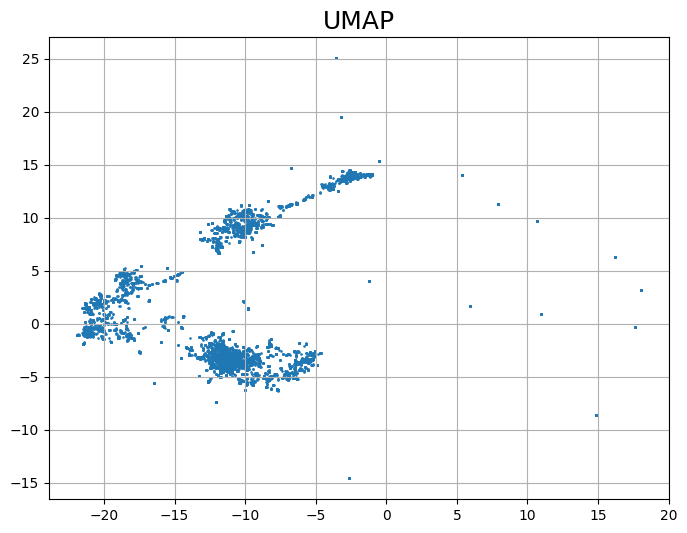

In [172]:
#Plotting the projection of data:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=0.8)
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

In [196]:
np.argmax(umap_2D_projection[:, 1])

np.int64(2706)

In [ ]:
image_pixel_dataframe_no_NaN

,0,1,2,3,4,5,6,7,8,9,...,25493,25494,25495,25496,25497,25498,25499,price,rating,year
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,20.70,24.84,2026
1,0,0,0,0,0,0,0,0,0,0,...,24,24,22,19,18,4,2,13.00,61.13,2022
2,0,0,0,0,0,0,0,0,0,0,...,163,157,155,161,162,176,166,13.40,49.77,2024
3,0,0,0,0,0,0,0,0,0,0,...,55,0,0,0,0,0,0,6.00,18.55,2022
4,0,0,0,0,0,0,0,0,0,0,...,30,31,29,28,29,29,32,6.95,93.50,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8275,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5.20,14.94,2023
8276,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3.40,28.71,2026
8277,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5.50,55.95,2026
8278,0,0,0,0,0,0,0,0,0,0,...,7,5,84,63,50,38,25,16.45,52.41,2022


In [222]:
image_pixel_dataframe_norm

,0,1,2,3,4,5,6,7,8,9,...,25493,25494,25495,25496,25497,25498,25499,25500,25501,25502
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001646,0.001976,0.161127
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001201,0.001201,0.001101,0.000951,0.000901,0.000200,0.000100,0.000651,0.003059,0.101198
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.010300,0.009921,0.009795,0.010174,0.010237,0.011122,0.010490,0.000847,0.003145,0.127902
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002746,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000300,0.000926,0.100965
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001601,0.001654,0.001547,0.001494,0.001547,0.001547,0.001707,0.000371,0.004989,0.107999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7914,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000315,0.000904,0.122393
7915,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000165,0.001393,0.098279
7916,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000313,0.003186,0.115371
7917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000386,0.000276,0.004638,0.003478,0.002760,0.002098,0.001380,0.000908,0.002894,0.111632


#### Clustering Algorithm results:

##### KMeans

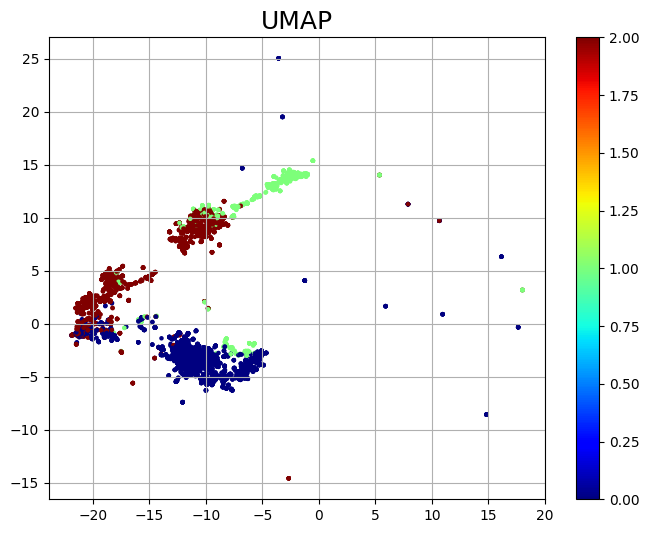

In [221]:
#KMeans as a simple version first:
kmeans = cluster.KMeans(n_clusters=3, n_init="auto").fit(image_pixel_dataframe_norm)
colours = kmeans.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5, c = colours, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

(10.0, 70.0)

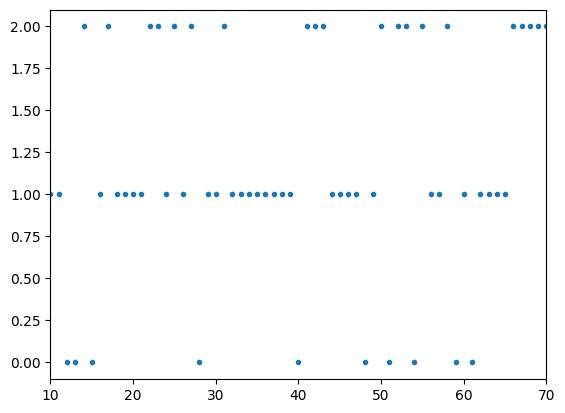

In [192]:
#Plotting the labels to check for patterns:
plt.plot(kmeans.labels_, ".")
plt.xlim(10, 70)

##### DBSCAN

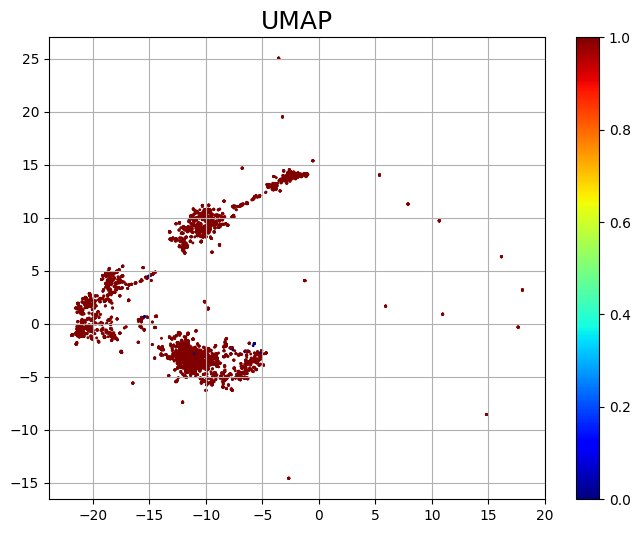

In [183]:
dbscan = cluster.DBSCAN(eps=0.7, min_samples=15).fit(image_pixel_dataframe_norm)
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=1.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

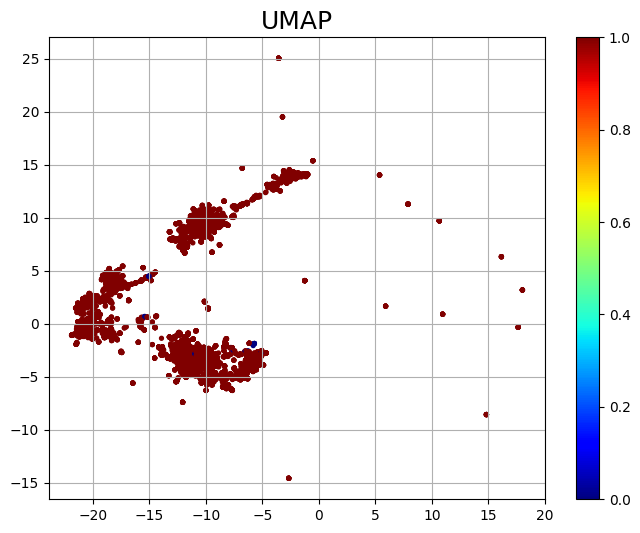

In [186]:
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=7.8, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

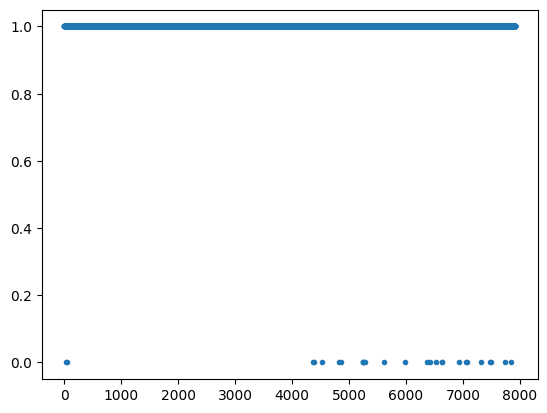

In [185]:
plt.plot(dbscan.labels_+1, ".")